# **Daily Household Transactions**

- **Domain:** Finance Analytics  
- **Project Type:** Exploratory Data Analysis (EDA)  
- **Tools Used:** Excel, Python, Pandas, NumPy, Matplotlib, Seaborn
- **Level:** Intermediate

## **Introduction**
The "Daily Transactions" dataset contains information on dummy transactions made by an individual on a daily basis. The dataset includes data on the products that were purchased, the amount spent on each product, the date and time of each transaction, the payment mode of each transaction, and the source of each record (Expense/Income).

## **Objectives**

- Analyze the daily household transactions
- Identify High paid categories and subcategories
- understand monthly and yearly trends of household transactions and payment modes of transactions
  

## **Dataset Description**
- The Dataset contains Daily Transactions contains information on dummy transactions made by
an individual on a daily basis.
- The dataset includes data on the products that were
purchased, the amount spent on each product, the date and time of each transaction,
the payment mode of each transaction, and the source of each record
(Expense/Income)

## Key Columns
- **Date**:  The date and time when the transaction was made
- **Mode**:  The payment mode used for the transaction
- **Category**:  Each record is divided into a set of categories of transactions
- **Subcategory**:  Categories are further broken down into Subcategories of
transactions
- **Note**:  A brief description of the transaction made
- **Amount**:  The transactional amount
- **Income/Expense**:  The indicator of each transaction representing either expense
or income
- **Currency**:  All transactions are recorded in official currency of India
  
 The dataset is used to perform data cleaning, exploratory data analysis and to understand daily household transactions 

## Step 1: Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import re
from scipy.stats import mode
import warnings
warnings.filterwarnings('ignore')

In [2]:
data= pd.read_csv(r"C:\Users\Sumathi\Downloads\Daily Household Transactions.csv", index_col=False)

In [3]:
# Used to clean and re-order the DataFrame index 
data = data.reset_index(drop=True)

In [4]:
# Display all columns,rows and removes floating values have more than 2 values after decimal like 10.12345

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [5]:
data.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20-09-2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.00,Expense,INR
1,20-09-2018 12:03:15,Cash,Food,Snacks,Idli medu Vada mix 2 plates,60.00,Expense,INR
2,19-09-2018 00:00:00,Saving Bank account 1,subscription,Netflix,1 month subscription,199.00,Expense,INR
3,17-09-2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.00,Expense,INR
4,16-09-2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.00,Expense,INR


## Step 2: Data Overview and Understanding

In this step, the dataset is explored to understand its structure, data types, and basic statistics.
This helps identify missing values, incorrect data types, and gives an overall idea of the dataset before cleaning.

In [6]:
#displays the shape of the data set

data.shape

(2461, 8)

In [7]:
# Check basic information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


In [8]:
# statistical summary of numerical columns

data.describe()

,Amount
count,2461.00
mean,2751.15
std,12519.62
min,2.00
25%,35.00
50%,100.00
75%,799.00
max,250000.00


In [9]:
# column names

data.columns

Index(['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount',
       'Income/Expense', 'Currency'],
      dtype='object')

In [76]:
data["Subcategory"].unique()

array(['Train', 'Snacks', 'Netflix', 'Mobile Service Provider',
       'Ganesh Pujan', 'Tata Sky', 'Auto', 'Grocery', 'Lunch', 'Milk',
       'Laundry', 'Breakfast', 'Dinner', 'Sweets', 'Kirana', 'Ice Cream',
       'Curd', 'Biscuits', 'Navratri', 'Tea', 'Flour Mill', 'Appliances',
       'Home Decor', 'Grooming', 'Health', 'Clothing', 'Clothes',
       'Chocolate', 'Medicine', 'Eating Out', 'Movie', 'Fruits', 'Potato',
       'Onions', 'Taxi', 'Hardware', 'Eggs', 'Bread', 'Petrol',
       'Hospital', 'Lab Tests', 'Bus', 'Travels', 'Kitchen', 'Footwear',
       'Entry Fees', 'Gadgets', 'Accessories', 'Misc', 'Stationary',
       'Rajgira Ladu', 'Newspaper', 'Toiletries', 'Bike', 'Beverage',
       'Makeup', 'Vegetables', 'Books', 'Holi', 'Courier', 'Leisure',
       'Updation', 'Amazon Prime', 'Edtech Course', 'Pocket Money',
       'Hotstar', 'Diwali', 'Wifi Internet Service', 'Trip', 'Furniture',
       'Water', 'Cable Tv', 'Ropeway', 'Rd', 'Lic', 'Saloon', 'Gift',
       'Rakshaband

## Step 3: Data Cleaning

In [10]:
#removes extra spaces or symbols on coloumn headings

[re.sub(r'[\s/]+', '_', x.strip()) for x in data.columns]

['Date',
 'Mode',
 'Category',
 'Subcategory',
 'Note',
 'Amount',
 'Income_Expense',
 'Currency']

In [11]:
print("Missing values before cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64


In [12]:
print('Missing data %',round(635/data.shape[0]*100,2))

Missing data % 25.8


In [13]:
data.dropna(inplace = True)

In [14]:
print("Missing values after cleaning:")
data.isnull().sum()

Missing values after cleaning:


Date              0
Mode              0
Category          0
Subcategory       0
Note              0
Amount            0
Income/Expense    0
Currency          0
dtype: int64

In [15]:
data.drop_duplicates(inplace=True)


In [16]:
data.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20-09-2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.00,Expense,INR
1,20-09-2018 12:03:15,Cash,Food,Snacks,Idli medu Vada mix 2 plates,60.00,Expense,INR
2,19-09-2018 00:00:00,Saving Bank account 1,subscription,Netflix,1 month subscription,199.00,Expense,INR
3,17-09-2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.00,Expense,INR
4,16-09-2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.00,Expense,INR


In [17]:
data.dtypes

Date               object
Mode               object
Category           object
Subcategory        object
Note               object
Amount            float64
Income/Expense     object
Currency           object
dtype: object

In [18]:
data['Date']=pd.to_datetime(data['Date'])
data['Amount']=data['Amount'].astype(float)
text_cols = ['Category', 'Subcategory', 'Mode', 'Currency','Income/Expense']

for col in text_cols:
    data[col] = data[col].astype(str).str.strip()


In [19]:
# data types of columns after converting 

data.dtypes

Date              datetime64[ns]
Mode                      object
Category                  object
Subcategory               object
Note                      object
Amount                   float64
Income/Expense            object
Currency                  object
dtype: object

## Final Cleaned Data

In [20]:
data.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,2018-09-20 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.00,Expense,INR
1,2018-09-20 12:03:15,Cash,Food,Snacks,Idli medu Vada mix 2 plates,60.00,Expense,INR
2,2018-09-19 00:00:00,Saving Bank account 1,subscription,Netflix,1 month subscription,199.00,Expense,INR
3,2018-09-17 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.00,Expense,INR
4,2018-09-16 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.00,Expense,INR


In [21]:
data.tail()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
2329,2015-02-23 19:37:47,Cash,Transportation,Train,Place 0 to Bandra,20.00,Expense,INR
2330,2015-02-23 18:39:59,Cash,Apparel,Footwear,shoe polish,20.00,Expense,INR
2331,2015-02-23 15:43:13,Credit Card,Transportation,Train,to and fro Mum to BRC,526.00,Expense,INR
2333,2015-02-19 20:52:01,Cash,Health,Health,face mask,45.00,Expense,INR
2334,2015-02-19 20:51:37,Cash,Health,Medicine,koflet,34.00,Expense,INR


## Data Profiling using YdataProfiling

YData Profiling is used to generate an automated and detailed report of the dataset. It helps to quickly understand data types, missing values, distributions, correlations, and potential data quality issues.

In [22]:
from ydata_profiling import ProfileReport

In [23]:
profile = ProfileReport(data, title="Daily Household Transactions", explorative=True)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 145.21it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
%matplotlib inline



# Step 4: Exploratory Data Analysis(EDA)

## EDA 1: Top 10 Expensive Subcategories

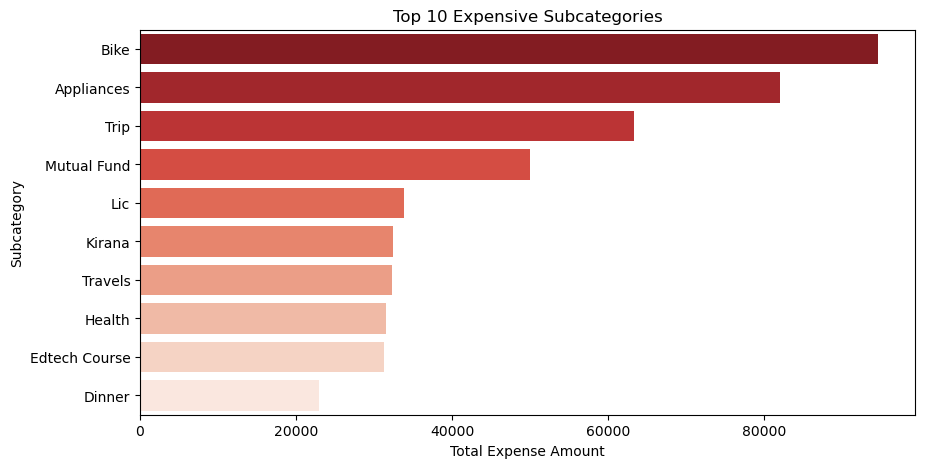

In [25]:
# Consider only Expense transactions
expense_df = data[data["Income/Expense"] == "Expense"]

# Aggregate total amount by Subcategory
subcat_expense = expense_df.groupby("Subcategory")["Amount"].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=subcat_expense.values, y=subcat_expense.index, palette="Reds_r")

plt.title("Top 10 Expensive Subcategories")
plt.xlabel("Total Expense Amount")
plt.ylabel("Subcategory")

# Save the figure
plt.savefig("top_10_expensive_subcategories.png")

plt.show()


**Conclusion:**  

- Bike is the highest expense subcategory, indicating a major one-time or high-value purchase.

- Appliances rank second, suggesting significant spending on household or electronic items.

- Trip expenses are also high, reflecting substantial travel-related costs.

- Mutual Fund appears among the top expenses, showing a focus on long-term investment, not just consumption.

- Mid-level expenses such as Lic, Kirana, Travels, and Health represent regular but important financial commitments.

- Edtech Course and Dinner contribute comparatively lower amounts among the top 10, indicating discretionary spending.

## EDA 2: Transaction counts by category

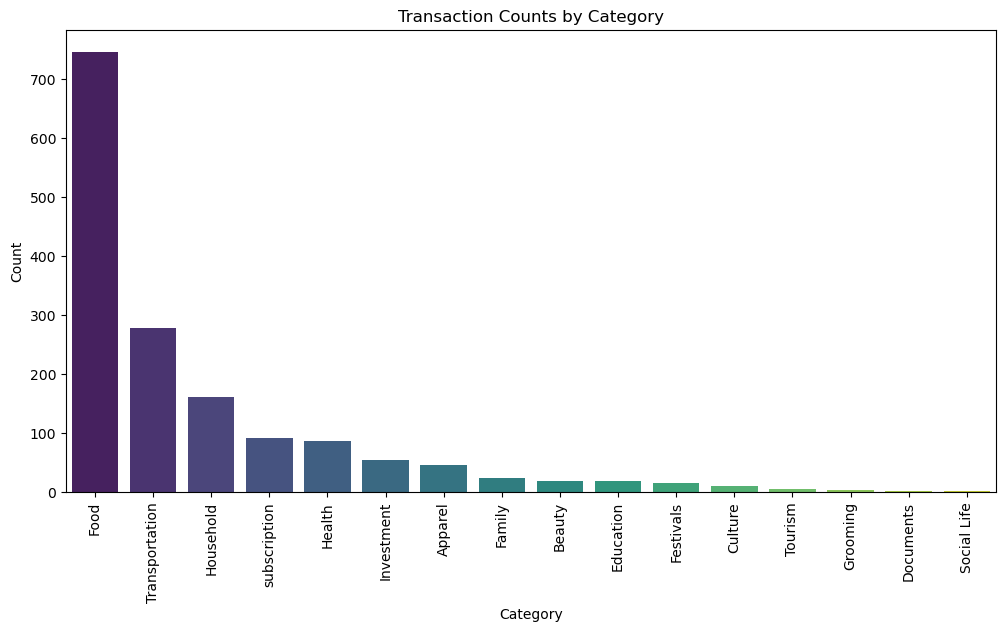

In [26]:
#Transaction counts by category

plt.figure(figsize=(12,6))
sns.countplot(data=data,x='Category',order=data['Category'].value_counts().index, palette="viridis")
plt.title('Transaction Counts by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.savefig('Transaction counts by category')
plt.show()


**Conclusion:** 

A major portion of total expenses is concentrated in only a few categories like food, transportation, household. categories account for the highest spending, indicating that financial control measures should primarily focus on these areas to effectively reduce overall expenses

## EDA 3: Mode of Payment

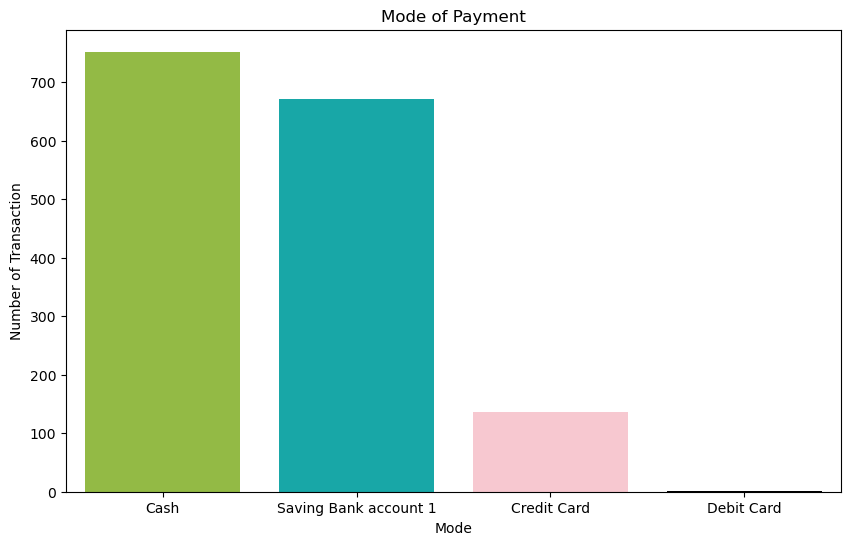

In [27]:
# Payment Mode
plt.figure(figsize=(10,6))

sns.countplot(
    x='Mode',
    data=data,
    palette=["yellowgreen", "c", "pink", "k"])

plt.title("Mode of Payment")
plt.xlabel("Mode")
plt.ylabel("Number of Transaction")
plt.savefig('Payment Mode')
plt.show()

**Conclusion:** 

- **Cash:**  Cash is the most dominant payment mode, accounting for the highest number of transactions. This indicates a strong reliance on cash for everyday expenses.

- **Saving Bank Account 1**  Saving Bank Account 1 is the second most frequently used mode, showing substantial adoption of bank-based or digital transactions.

- **Credit Card** Credit Card usage is comparatively low, suggesting limited dependence on credit facilities.

- **Debit Card** Debit Card usage is negligible or almost absent, indicating it is rarely used for transactions in this dataset.

## EDA 4: Which month has highest spending

In [28]:

# Convert Date column to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Create Month column
data["Month"] = data["Date"].dt.to_period("M")


In [29]:
expense_data = data[data["Income/Expense"] == "Expense"]


In [30]:
monthly_expense = expense_data.groupby("Month")["Amount"].sum().reset_index()


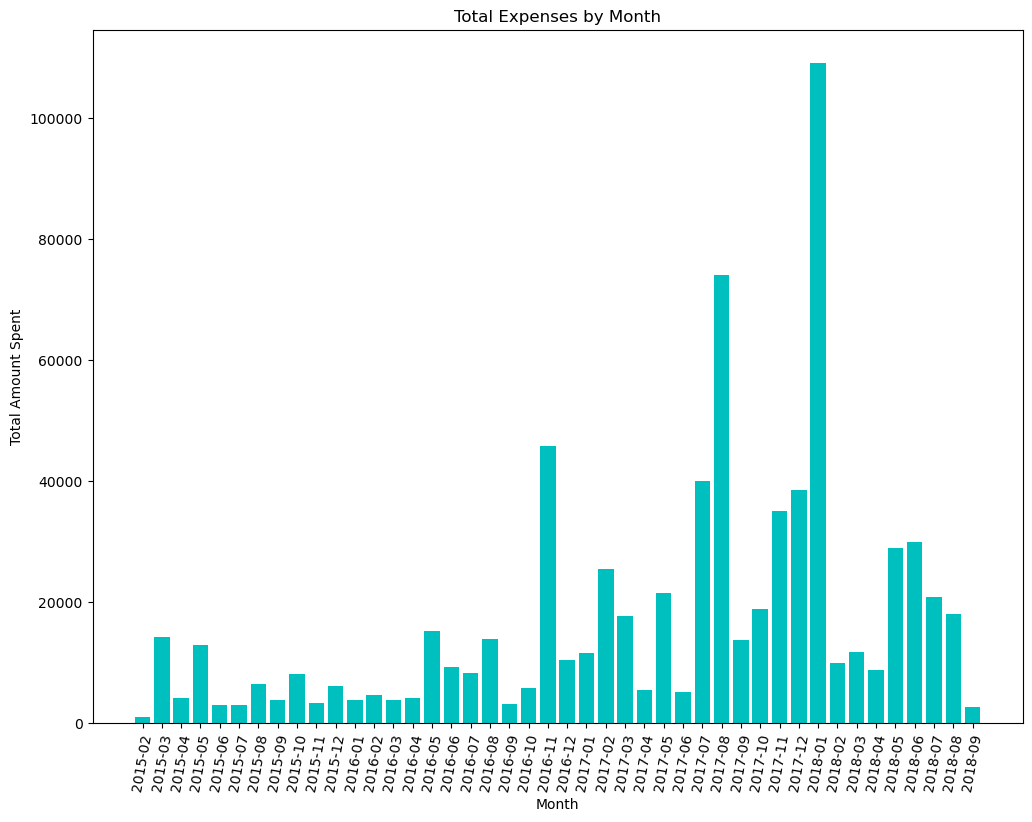

In [31]:
plt.figure(figsize=(12,9))

plt.bar(monthly_expense["Month"].astype(str), monthly_expense["Amount"], color="c")

plt.title("Total Expenses by Month")
plt.xlabel("Month")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=80)
plt.savefig("Total Expenses by Month")
plt.show()


In [32]:
highest = monthly_expense.loc[monthly_expense["Amount"].idxmax()]

print("Highest Spending Month:")
print(highest)


Highest Spending Month:
Month      2018-01
Amount   109125.90
Name: 35, dtype: object


**Conclusion:**  
- Lower and stable amounts are observed during the early period (2015–early 2016), indicating limited financial activity.

- From late 2016 onward, there is a clear increase in monthly transaction amounts, reflecting growth in spending or income.

- Several sharp peaks appear in 2017 and early 2018, representing high-value or one-time financial events such as investments, major purchases, or travel.

- The highest transaction amount occurs around early 2018, marking a significant financial outflow or inflow during that month.

- Post-peak months show a decline, suggesting that the extreme values are event-driven rather than sustained.

## EDA 5: Is spending increasing or decreasing over years?

In [67]:
# Step 1 – Prepare Date and Year Column


# Convert Date to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Extract Year
data["Year"] = data["Date"].dt.year


In [68]:
# Step 2 – Filter Only Expenses

expense_data = data[data["Income/Expense"] == "Expense"]

In [69]:
# Step 3 – Aggregate Spending by Year

yearly_expense = expense_data.groupby("Year")["Amount"].sum().reset_index()

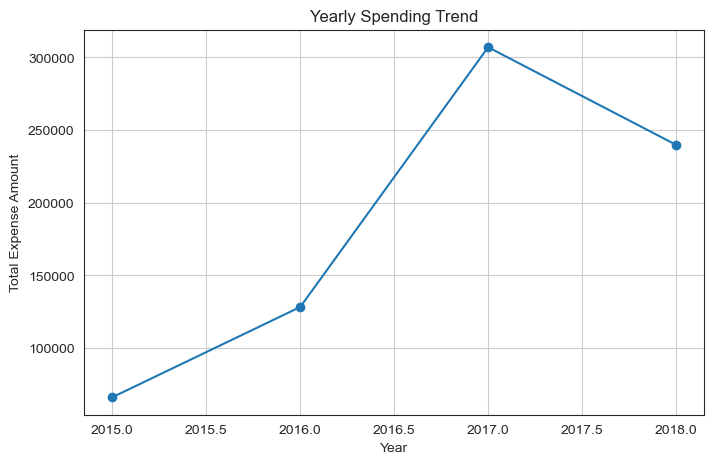

In [70]:
sns.set_style("white")
plt.figure(figsize=(8,5))

plt.plot(yearly_expense["Year"], yearly_expense["Amount"], marker="o")

plt.title("Yearly Spending Trend")
plt.xlabel("Year")
plt.ylabel("Total Expense Amount")
plt.grid()

# Save the figure
plt.savefig("yearly_spending_trend.png")

plt.show()


**Conclusion:**  
- 2015 shows the lowest total spending, indicating relatively limited financial activity.

- Spending increases steadily in 2016, suggesting growth in expenses or expansion in financial commitments.

- 2017 records the highest expenditure, marking a peak year with significant spending, possibly due to major purchases, investments, or life events.

- In 2018, total spending declines compared to 2017, but still remains higher than 2015 and 2016, indicating sustained but controlled expenses.

## EDA 6: Which category has highest expenses

In [60]:
# Step 1 – Filter Only Expense Records

expense_data = data[data["Income/Expense"] == "Expense"]

In [61]:
# Step 2 – Aggregate Amount by Category
category_expense = expense_data.groupby("Category")["Amount"].sum().reset_index()

# Step 3 – Sort Categories (Optional but Better)

category_expense = category_expense.sort_values(by="Amount", ascending=False)

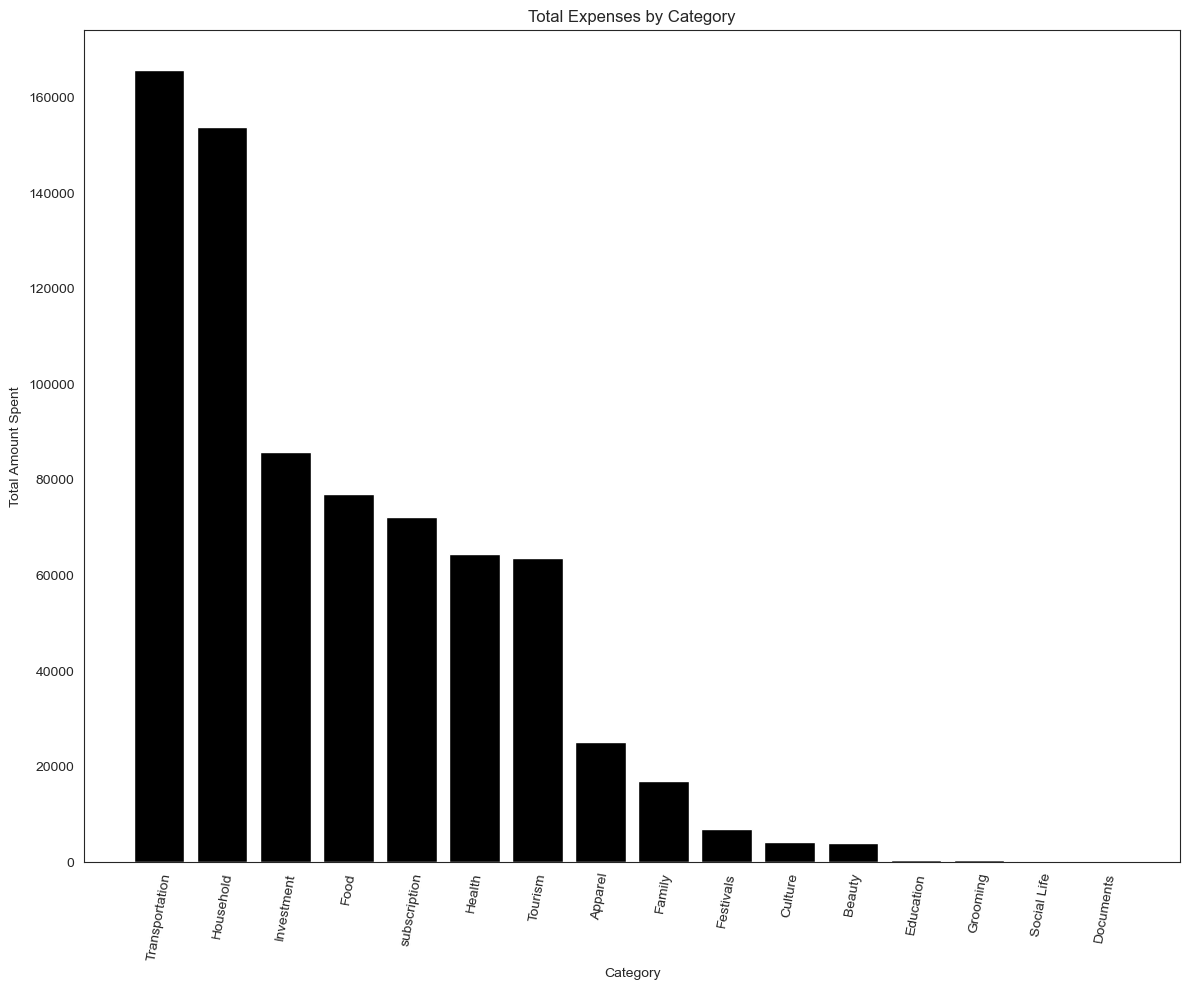

In [74]:
sns.set_style("white")
plt.figure(figsize=(12,10))

plt.bar(category_expense["Category"], category_expense["Amount"], color="k")

plt.title("Total Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=80)

# Save the chart
plt.savefig("category_expense.png")
plt.tight_layout()
plt.show()


In [40]:
highest = category_expense.iloc[0]
print("Highest Expense Category:")
print(highest)


Highest Expense Category:
Category    Transportation
Amount           165738.78
Name: 14, dtype: object


**Conclusion:**  

We can observe that total expenses by category. Transporation is Highest Expense category after that household, investment, food, subscription, health, tourism are taking most amount. so we need to concentrate on those 7 categories while spending money on that categories.

## EDA 7: Expense Distribution Across top 7 Categories

In [41]:
# Step 1 – Filter Only Expense Records
expense_data = data[data["Income/Expense"] == "Expense"]

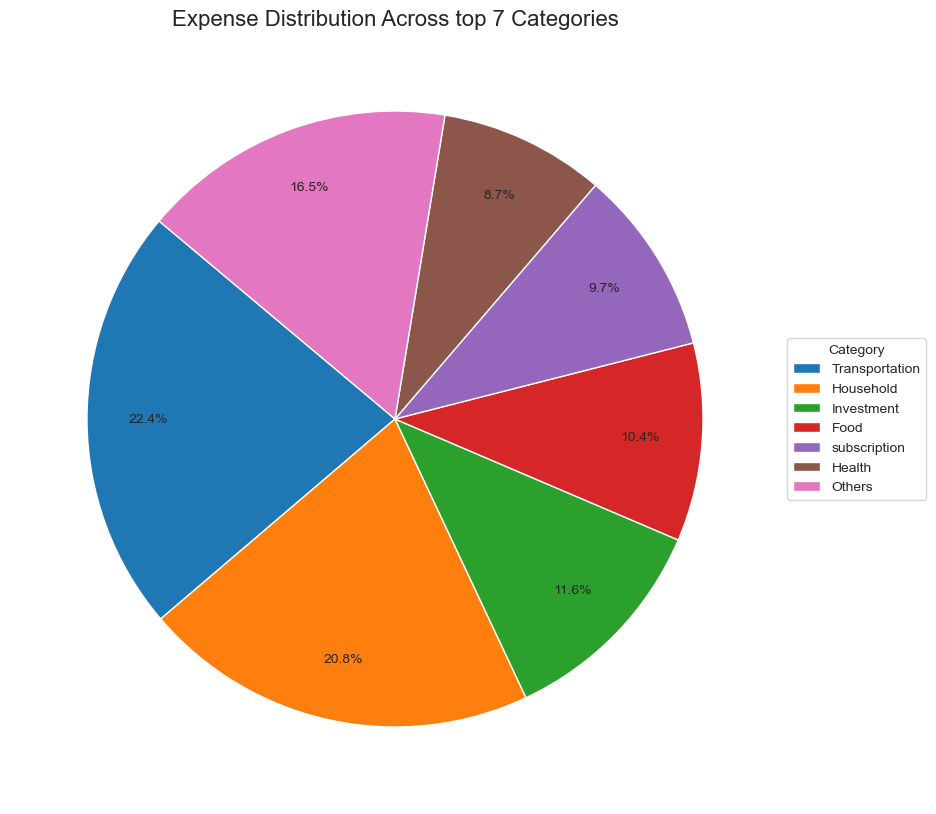

In [57]:

# Step 1: Aggregate expense by category
category_expense = expense_data.groupby("Category")["Amount"].sum()

# Step 2: Sort and take top 6 categories
top_n = 6
top_categories = category_expense.sort_values(ascending=False).head(top_n)

# Step 3: Group remaining categories as "Others"
others = category_expense.sort_values(ascending=False).iloc[top_n:].sum()

# Step 4: Create final data
final_data = top_categories.copy()
final_data["Others"] = others

# Step 5: Plot clean pie chart
plt.figure(figsize=(10, 10))

wedges, texts, autotexts = plt.pie(
    final_data,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white'}
)

# Step 6: Add legend instead of labels on pie
plt.legend(
    wedges,
    final_data.index,
    title="Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Expense Distribution Across top 7 Categories", fontsize=16)

# Save figure
plt.savefig("expense_distribution_clean.png", bbox_inches="tight")

plt.show()


**Conclusion:**  
- Transportation (22.4%) is the largest expense category, indicating significant spending on travel, commuting, or vehicle-related costs.

- Household (20.8%) is the second-highest contributor, reflecting substantial day-to-day living and home maintenance expenses.

- Others (16.5%) represents a combined share of multiple minor categories, showing that small but frequent expenses together form a meaningful portion of total spending.

- Investment (11.6%) and Food (10.4%) account for a moderate share, highlighting a balance between financial planning and essential consumption.

- Subscription (9.7%) and Health (8.7%) have comparatively smaller but consistent expense contributions.

In [ ]:
EDA: 8 

In [ ]:
data["Category"].value_counts()

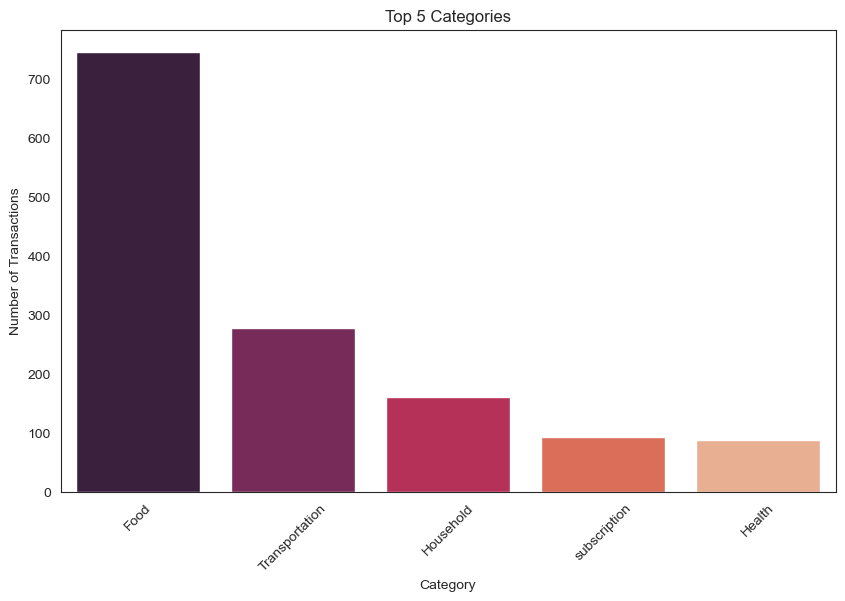

In [75]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=data,
    x="Category",
    order=data["Category"].value_counts().iloc[:5].index,
    palette="rocket")   # you can change to 'viridis', 'rocket', 'coolwarm', etc.

plt.title("Top 5 Categories")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.show()

**Conclusions:**

Food dominates with the highest number of transactions, indicating frequent day-to-day spending.

Transportation ranks second, reflecting regular commuting or travel-related expenses.

Household transactions occur at a moderate frequency, suggesting periodic household needs.

Subscription and Health have comparatively fewer transactions, indicating less frequent but necessary expenses.

In [ ]:
## EDA: 9 

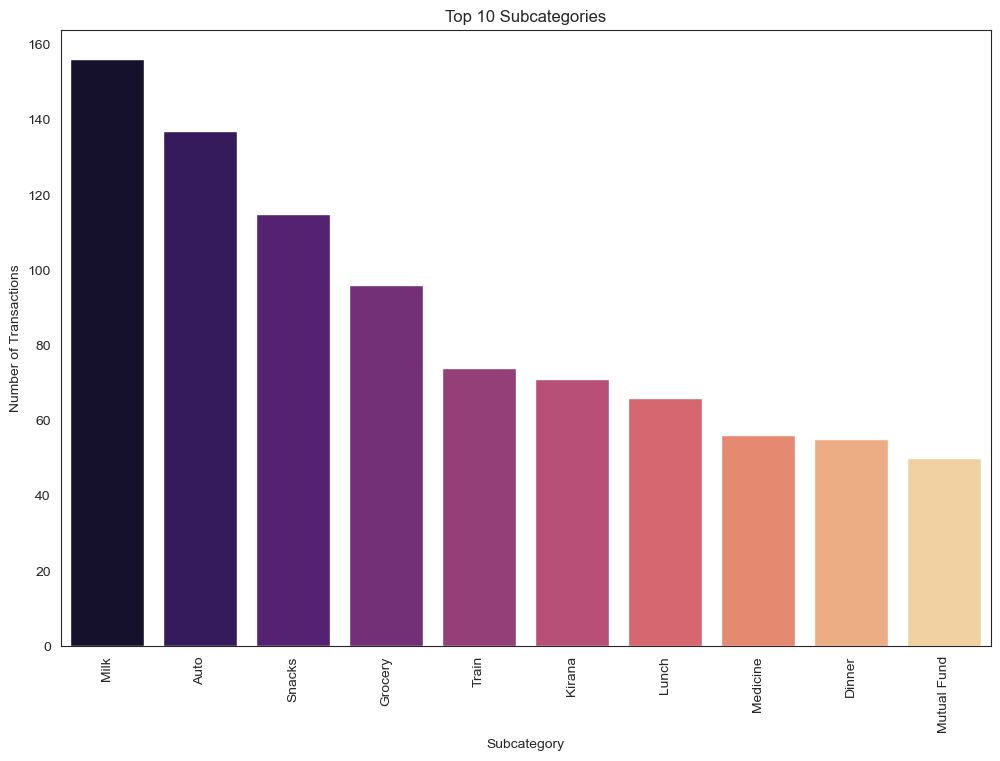

In [77]:
plt.figure(figsize=(12,8))

sns.countplot(
    data=data,
    x="Subcategory",
    order=data["Subcategory"].value_counts().iloc[:10].index,
    palette="magma")   # you can change to 'Set2', 'rocket', 'coolwarm', etc.


plt.title("Top 10 Subcategories")
plt.xlabel("Subcategory")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=90)
plt.savefig("Top 10 Subcategories")
plt.show()

**Conclusion:** 

The chart shows that Milk, Auto, and Snacks have the highest number of transactions, indicating frequent, routine spending. In contrast, Mutual Fund, Dinner, and Medicine have fewer transactions, suggesting less frequent or occasional expenses. Overall, daily essentials dominate transaction frequency, while investments and special expenses occur less often.

# Step 4: Time Series Analysis

Time Series Analysis is used to study data points collected over time to understand patterns, predict future values, and support better decisions

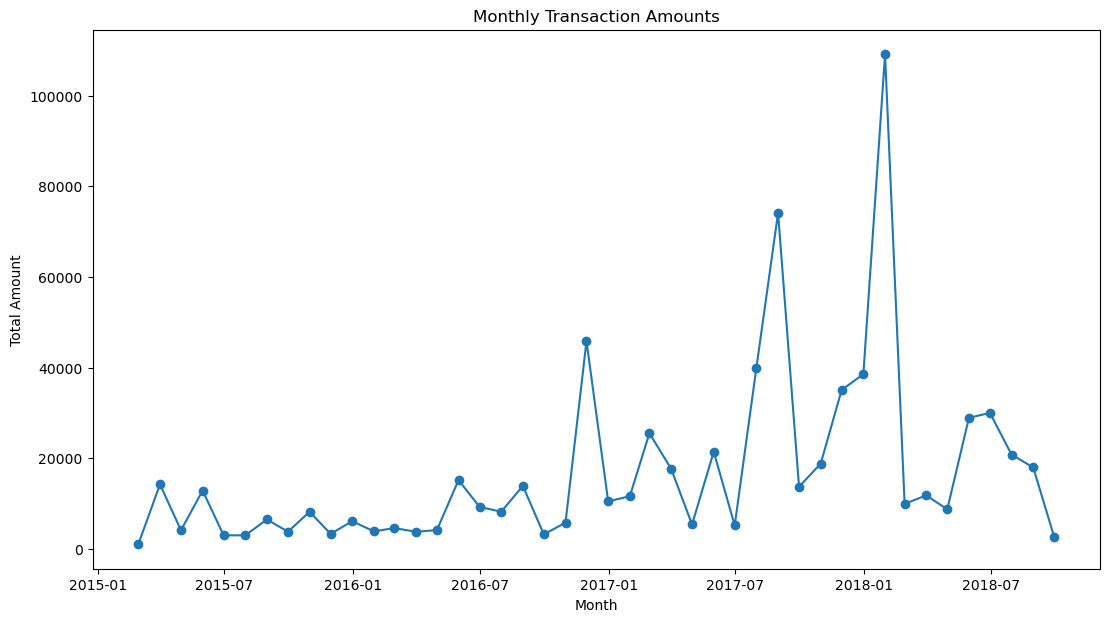

In [43]:
# monthly trends

monthly_data = data.resample('M', on='Date')['Amount'].sum()

plt.figure(figsize=(13, 7))
plt.plot(monthly_data.index, monthly_data.values, marker='o')
plt.title('Monthly Transaction Amounts')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.show()


**Conclusion:**  The monthly transaction analysis reveals a non-linear, upward-moving trend with significant fluctuations. While spending increases over time, it is characterized by sporadic high-value transactions, emphasizing the importance of monitoring and anomaly detection in financial data.

In [44]:
# Daily trends

data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
daily_data = data.groupby('Date')['Amount'].sum()



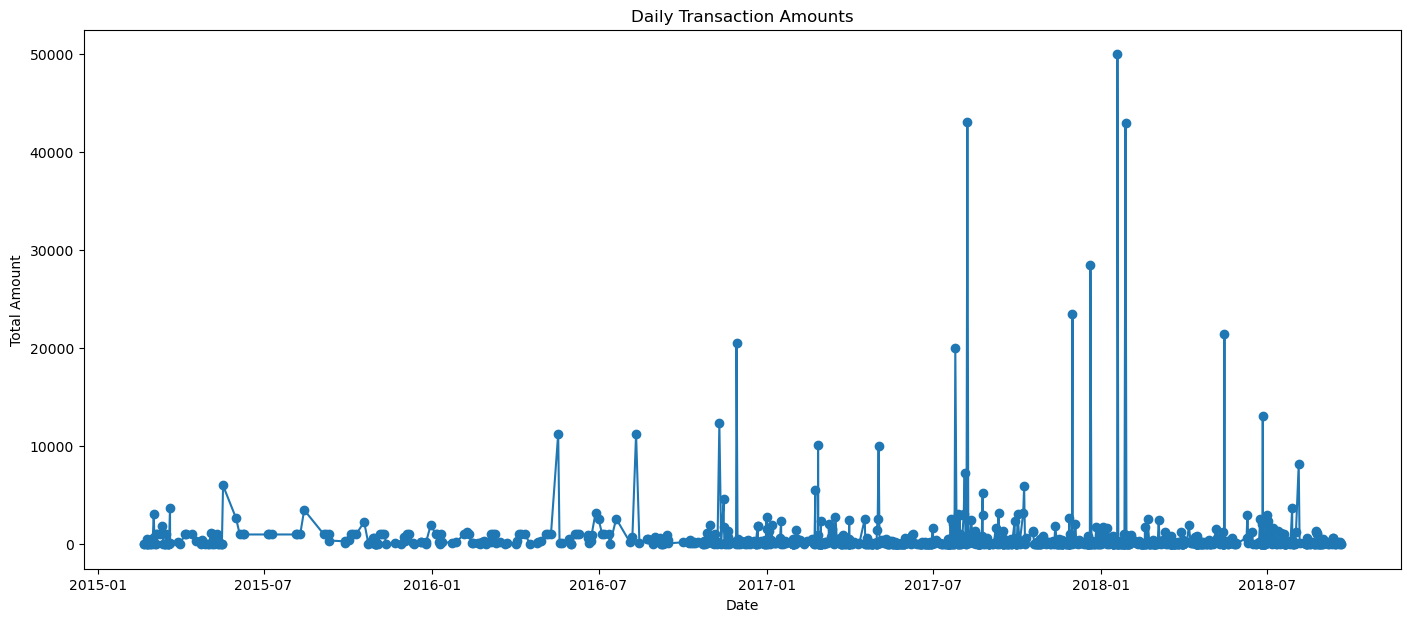

In [45]:
plt.figure(figsize=(17,7))
plt.plot(daily_data.index, daily_data.values, marker='o')
plt.title('Daily Transaction Amounts')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.show()


**Key conclusions:**

- Most daily transactions are low in value, clustering near the bottom of the chart, indicating routine, day-to-day spending.

- Occasional extreme spikes appear throughout the timeline, representing large one-time transactions such as investments, major purchases, or special events.

- The frequency and magnitude of spikes increase after 2016, suggesting growth in financial activity or higher-value transactions over time.

- There is no clear daily seasonality, meaning spending does not follow a consistent daily pattern.

- The data contains strong outliers, which significantly influence totals and explain why monthly aggregates show sharp peaks.

# Step 5: Correlation Analysis

Correlation analysis helps understand how strongly variables are related and in which direction.

Analyze the correlation between transaction categories and amounts.

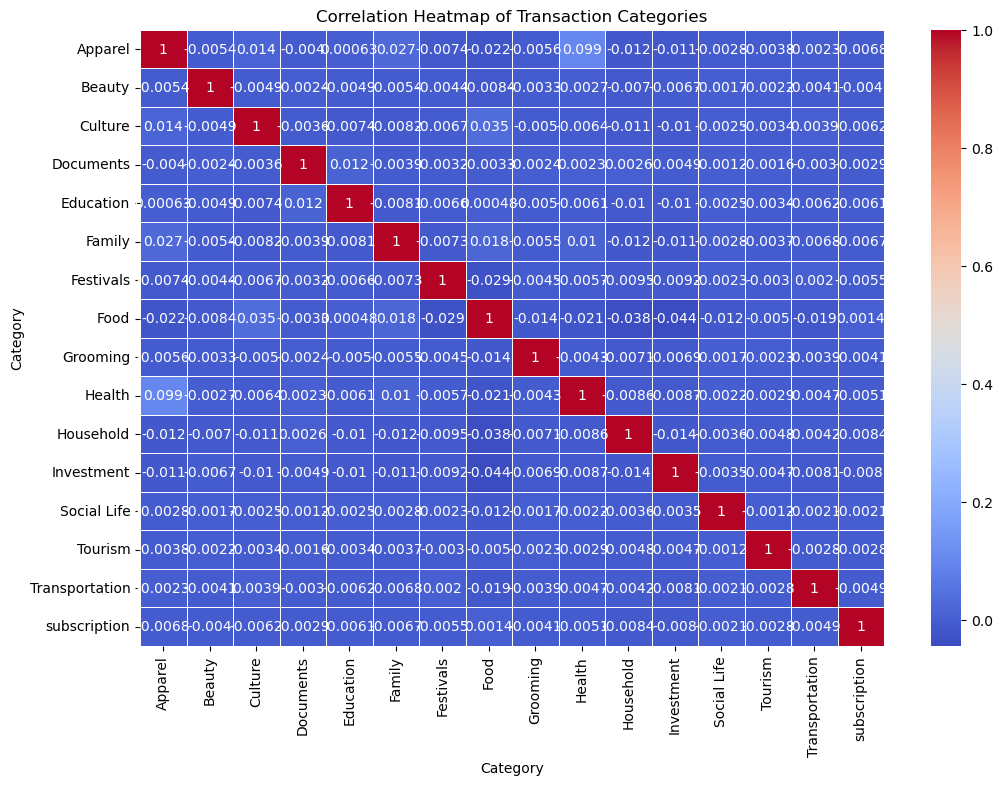

In [46]:
# Create a pivot table for correlation analysis
pivot_table = data.pivot_table(index='Date', columns='Category', values='Amount',aggfunc='sum', fill_value=0)
# Calculate correlation matrix
correlation_matrix = pivot_table.corr()
# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Transaction Categories')
plt.show()

**Conclusion:**  This heatmap shows that most spending categories have very weak correlations, indicating that expenses across categories are largely independent over time.

# Step 6: Generate Report

Summary
The financial transactions dataset was analyzed to identify key trends and insights. The
data cleaning process involved handling missing values, correcting data types, and
removing duplicates. Exploratory Data Analysis (EDA) revealed the distribution of
transaction amounts, transaction counts by category and type, and significant patterns
over time. Time series analysis highlighted monthly and daily transaction trends.
Correlation analysis identified relationships between different transaction categories.